Dataset shape: (150, 4)
Number of classes: 3

Neural Network Architecture:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323 (1.26 KB)

 Trainable params: 323 (1.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3333 - loss: 1.3091 - val_accuracy: 0.4167 - val_loss: 1.1190
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3438 - loss: 1.1427 - val_accuracy: 0.4583 - val_loss: 1.0045
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4167 - loss: 1.0130 - val_accuracy: 0.5000 - val_loss: 0.9155
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6458 - loss: 0.8989 - val_accuracy: 0.7083 - val_loss: 0.8460
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7917 - loss: 0.8126 - val_accuracy: 0.7083 - val_loss: 0.7879
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8438 - loss: 0.7406 - val_accuracy: 0.7083 - val_loss: 0.7394
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8438 - loss: 0.6822 - val_accuracy: 0.7083 - val_loss: 0.6964
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8438 - loss: 0.6333 - val_accuracy: 0.7083 - v

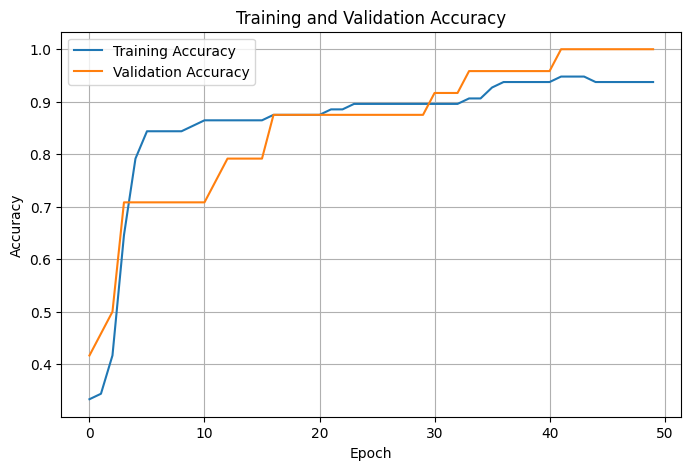

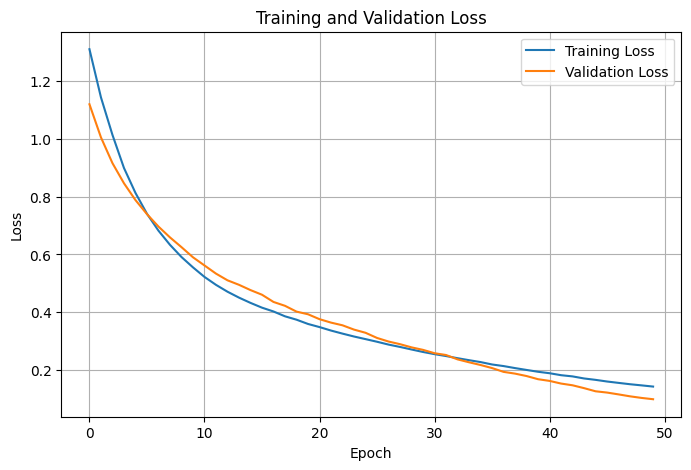

In [1]:
# Experiment 8: Feedforward Neural Network using TensorFlow/Keras

# Step 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load the dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 4: Standardize the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Build a Feedforward Neural Network using Keras
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(12, activation='relu'),
    Dense(3, activation='softmax')
])

# Step 6: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\nNeural Network Architecture:")
model.summary()

# Step 7: Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# Step 8: Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Step 9: Display accuracy and loss
print("\nTest Results")
print("------------")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Original Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Standardized Dataset:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]

Transformed Dataset:
   Principal Component 1  Principal Component 2
0              -2.264703               0.480027
1              -2.080961              -0.674134
2              -2.364229              -0.341908
3              -2.299384         

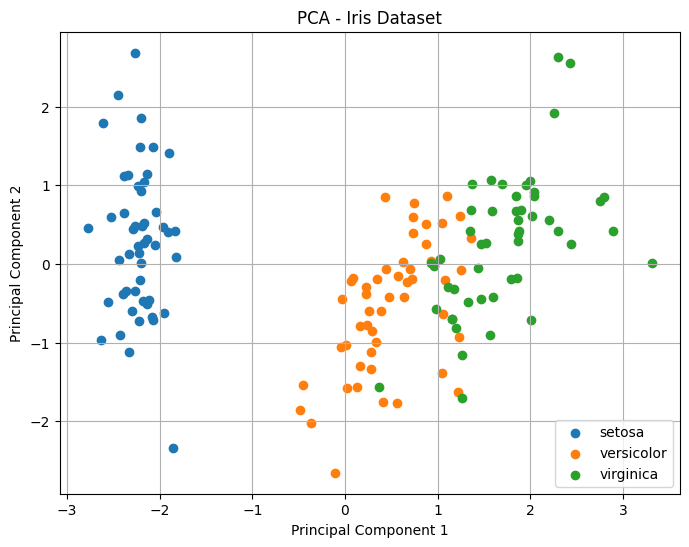

In [2]:
# Experiment 7: Dimensionality Reduction Using PCA

# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 2: Load the dataset
iris = load_iris()

X = iris.data
y = iris.target

# Create a DataFrame for displaying the original dataset
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

print("Original Dataset:")
print(df.head())

# Step 3: Standardize the dataset
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized Dataset:")
print(X_scaled[:5])

# Step 4: Apply PCA and choose the number of components
pca = PCA(n_components=2)

# Step 5: Transform the data into principal components
X_pca = pca.fit_transform(X_scaled)

# Step 6: Display the transformed dataset
pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

print("\nTransformed Dataset:")
print(pca_df.head(10))

# Display explained variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Preserved:")
print(sum(pca.explained_variance_ratio_))

# Step 7: Visualize the reduced data using a scatter plot

plt.figure(figsize=(8, 6))

for target in range(3):
    plt.scatter(
        X_pca[y == target, 0],
        X_pca[y == target, 1],
        label=iris.target_names[target]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Reshaped training data: (60000, 28, 28, 1)
Reshaped testing data: (10000, 28, 28, 1)

CNN Model Architecture:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9503 - loss: 0.1639 - val_accuracy: 0.9858 - val_loss: 0.0498
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.9846 - loss: 0.0492 - val_accuracy: 0.9872 - val_loss: 0.0416
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9894 - loss: 0.0331 - val_accuracy: 0.9897 - val_loss: 0.0372
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9921 - loss: 0.0245 - val_accuracy: 0.9903 - val_loss: 0.0385
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9940 - loss: 0.0183 - val_accuracy: 0.9905 - val_loss: 0.0330

Test Results
------------
Test Loss: 0.031809281557798386
Test Accuracy: 0.9900000095367432


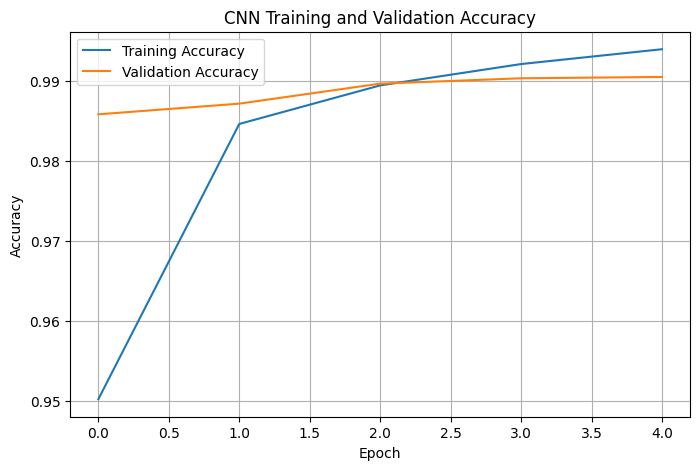

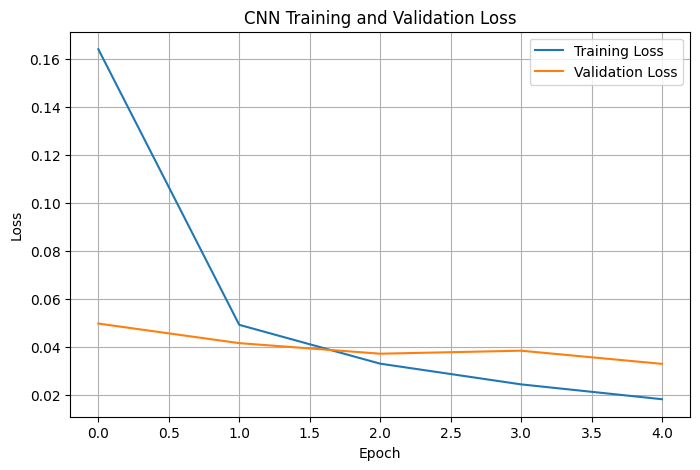

In [3]:
# Experiment 9: Image Classification Using CNN

# Step 1: Import required libraries
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Step 2: Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

# Step 3: Normalize the image pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Step 4: Reshape the dataset into CNN input format
# CNN expects: (samples, height, width, channels)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Reshaped training data:", X_train.shape)
print("Reshaped testing data:", X_test.shape)

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 6: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\nCNN Model Architecture:")
model.summary()

# Step 7: Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# Step 8: Evaluate the model on testing data
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Step 9: Display accuracy and loss
print("\nTest Results")
print("------------")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Training dataset shape: (60000, 28, 28, 1)

Generator Model:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,440 (966.56 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 233,985 (914.00 KB)

 Non-trainable params: 0 (0.00 B)


Starting GAN Training...
Epoch 1/20 - Generator Loss: 2.9273 - Discriminator Loss: 0.1595
Epoch 2/20 - Generator Loss: 4.1261 - Discriminator Loss: 0.0777
Epoch 3/20 - Generator Loss: 2.6538 - Discriminator Loss: 0.3276
Epoch 4/20 - Generator Loss: 2.3415 - Discriminator Loss: 0.3397
Epoch 5/20 - Generator Loss: 2.3775 - Discriminator Loss: 0.3415
Epoch 6/20 - Generator Loss: 2.7698 - Discriminator Loss: 0.3665
Epoch 7/20 - Generator Loss: 2.7801 - Discriminator Loss: 0.4527
Epoch 8/20 - Generator Loss: 2.5348 - Discriminator Loss: 0.4168
Epoch 9/20 - Generator Loss: 2.6751 - Discriminator Loss: 0.4114
Epoch 10/20 - Generator Loss: 2.7724 - Discriminator Loss: 0.4221
Epoch 11/20 - Generator Loss: 3.1929 - Discriminator Loss: 0.2463
Epoch 12/20 - Generator Loss: 3.1882 - Discriminator Loss: 0.2825
Epoch 13/20 - Generator Loss: 3.4009 - Discriminator Loss: 0.3033
Epoch 14/20 - Generator Loss: 3.3188 - Discriminator Loss: 0.2472
Epoch 15/20 - Generator Loss: 3.7565 - Discriminator Loss: 

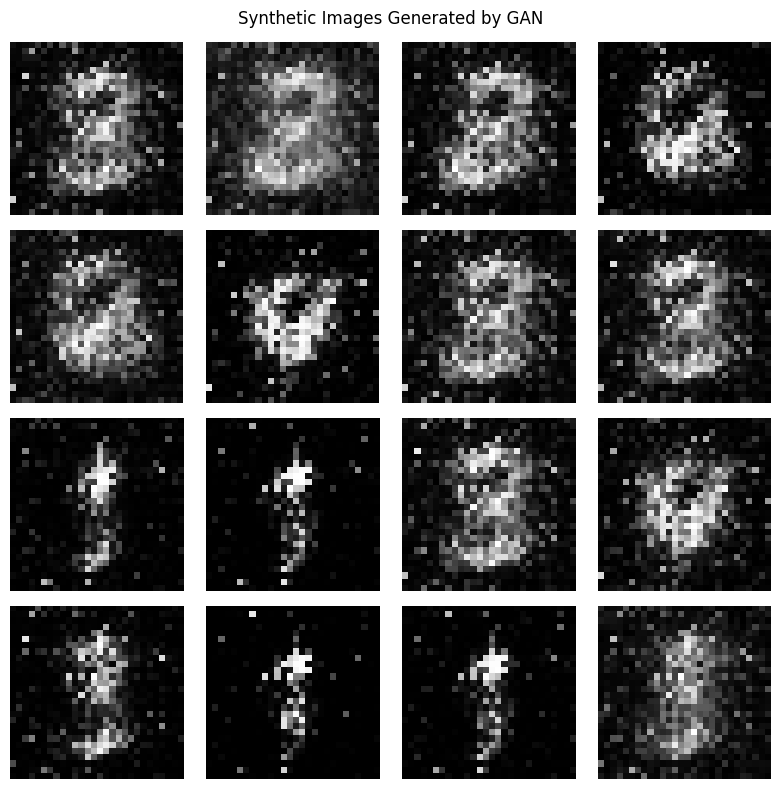

In [4]:
# Experiment 10: Synthetic Image Generation Using GAN

# Step 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Step 2: Load and preprocess the MNIST dataset
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images from [0, 255] to [-1, 1]
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)

print("Training dataset shape:", X_train.shape)

# Create TensorFlow dataset
batch_size = 128

dataset = tf.data.Dataset.from_tensor_slices(X_train)
dataset = dataset.shuffle(60000).batch(batch_size)

# Define latent dimension
latent_dim = 100

# Step 3: Build the Generator model
generator = Sequential([
    Dense(128, activation='relu', input_shape=(latent_dim,)),
    Dense(256, activation='relu'),
    Dense(28 * 28, activation='tanh'),
    Reshape((28, 28, 1))
])

print("\nGenerator Model:")
generator.summary()

# Step 4: Build the Discriminator model
discriminator = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

print("\nDiscriminator Model:")
discriminator.summary()

# Loss function and optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy()

generator_optimizer = Adam(learning_rate=0.0002)
discriminator_optimizer = Adam(learning_rate=0.0002)

# Step 5, 6 and 7: Define GAN training process

@tf.function
def train_step(real_images):

    batch_size_current = tf.shape(real_images)[0]

    # Generate random noise
    noise = tf.random.normal(
        [batch_size_current, latent_dim]
    )

    # Generate fake images
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        fake_images = generator(noise, training=True)

        # Discriminator predictions
        real_output = discriminator(
            real_images,
            training=True
        )

        fake_output = discriminator(
            fake_images,
            training=True
        )

        # Calculate discriminator loss
        real_loss = cross_entropy(
            tf.ones_like(real_output),
            real_output
        )

        fake_loss = cross_entropy(
            tf.zeros_like(fake_output),
            fake_output
        )

        discriminator_loss = real_loss + fake_loss

        # Calculate generator loss
        generator_loss = cross_entropy(
            tf.ones_like(fake_output),
            fake_output
        )

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        generator_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        discriminator_loss,
        discriminator.trainable_variables
    )

    # Update model weights
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return generator_loss, discriminator_loss


# Step 8: Repeat training for several epochs

epochs = 20

print("\nStarting GAN Training...")

for epoch in range(epochs):

    gen_loss_total = 0
    disc_loss_total = 0
    batches = 0

    for real_images in dataset:

        gen_loss, disc_loss = train_step(real_images)

        gen_loss_total += gen_loss
        disc_loss_total += disc_loss
        batches += 1

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Generator Loss: {gen_loss_total / batches:.4f} "
        f"- Discriminator Loss: {disc_loss_total / batches:.4f}"
    )

# Step 9: Generate synthetic images after training

num_images = 16

noise = tf.random.normal(
    [num_images, latent_dim]
)

generated_images = generator(
    noise,
    training=False
)

# Display generated images
plt.figure(figsize=(8, 8))

for i in range(num_images):

    plt.subplot(4, 4, i + 1)

    # Convert from [-1, 1] to [0, 1]
    image = (generated_images[i] + 1) / 2

    plt.imshow(image[:, :, 0], cmap='gray')
    plt.axis('off')

plt.suptitle("Synthetic Images Generated by GAN")
plt.tight_layout()
plt.show()

In [6]:
# Experiment 11: Hyperparameter Tuning with Grid Search

# Step 1: Import required libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 2: Load the dataset
iris = load_iris()

X = iris.data
y = iris.target

# Step 3: Split data into features and target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 4: Define the model
model = RandomForestClassifier(random_state=42)

# Step 5: Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Step 6: Apply GridSearchCV with cross-validation
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# Step 7: Train the model on all parameter combinations
grid_search.fit(X_train, y_train)

# Step 8: Find the best parameters and best score
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

# Step 9: Display the optimal model settings
best_model = grid_search.best_estimator_

print("\nOptimal Model:")
print(best_model)

# Evaluate the best model on test data
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:")
print(test_accuracy)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation Score:
0.95

Optimal Model:
RandomForestClassifier(n_estimators=50, random_state=42)

Test Accuracy:
0.9
